## Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the data and create the DataFrame
data = pd.read_csv('freelancer_income_data.csv')
df = pd.DataFrame(data)

## Exploration

In [2]:
# Initial exploration
df.head()

,Invoice Date,Client,Service,Amount,Payment Date,Status
0,9/12/2024,ABC Corp,Web Scraping,450,9/15/2024,Paid
1,9/20/2024,XYZ Ltd,RPA Audit,600,9/25/2024,Paid
2,10/1/2024,Freelance Co,Data Cleanup,300,NaN,Unpaid
3,10/5/2024,Tech Solutions,Data Analysis,500,10/10/2024,Paid
4,10/10/2024,Creative Agency,Web Development,700,10/15/2024,Paid


In [3]:
# Further exploration
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Invoice Date  12 non-null     object
 1   Client        12 non-null     object
 2   Service       12 non-null     object
 3   Amount        12 non-null     int64 
 4   Payment Date  8 non-null      object
 5   Status        12 non-null     object
dtypes: int64(1), object(5)
memory usage: 708.0+ bytes


,Amount
count,12.000000
mean,487.500000
std,140.008117
min,300.000000
25%,387.500000
50%,475.000000
75%,600.000000
max,700.000000


## Visualizations

### Client Distribution Pie Chart

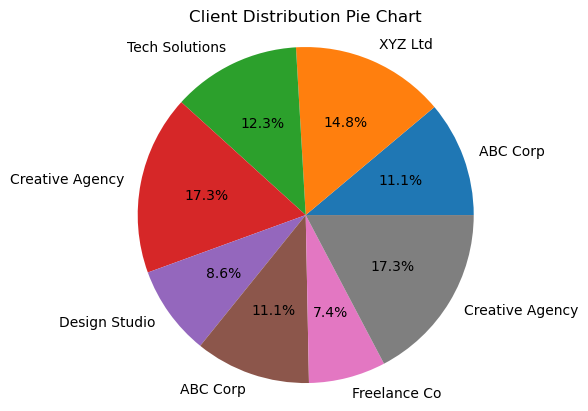

In [4]:
# Filter the DataFrame for 'Paid' status
paid_clients = df[df['Status'] == 'Paid']

# Get the clients and their corresponding amounts
clients = paid_clients['Client']
amounts = paid_clients['Amount']

# Create the pie chart
plt.pie(amounts, labels = clients, autopct='%1.1f%%')

# Add title and axis
plt.title('Client Distribution Pie Chart')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular

# Show the plot
plt.show()

### Top 5 Most Profitable Services (Bar Chart)

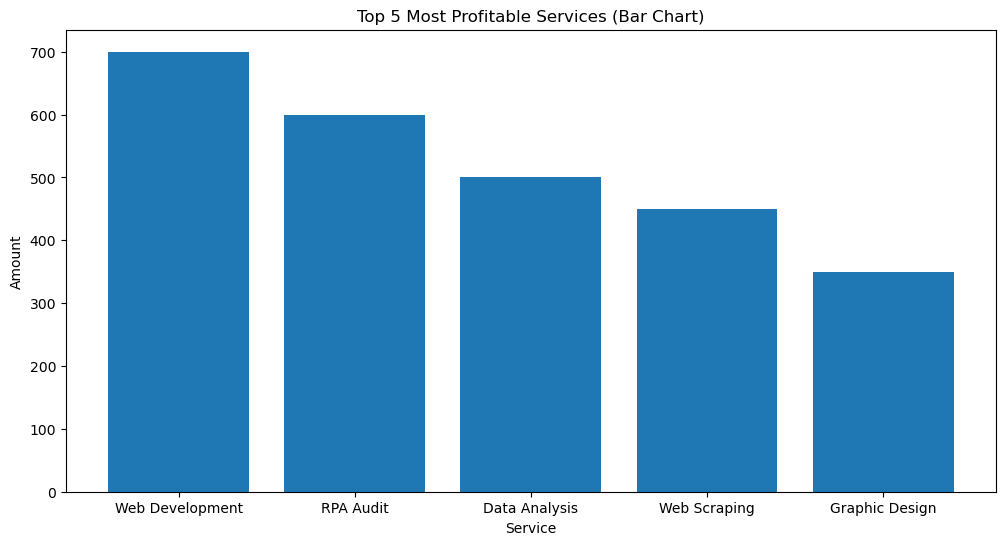

In [5]:
# Filter the DataFrame for 'Paid' status
paid_services = df[df['Status'] == 'Paid']

# Sort the filtered DataFrame by 'Amount' in descending order and drop duplicates
top_services = paid_services.sort_values(by='Amount', ascending=False).drop_duplicates(subset='Amount').head(5)

# Set the figure size
plt.figure(figsize=(12, 6))  # Width: 12 inches, Height: 6 inches

# Create a bar chart
plt.bar(top_services['Service'], top_services['Amount'])

# Add labels and title
plt.xlabel('Service')
plt.ylabel('Amount')
plt.title('Top 5 Most Profitable Services (Bar Chart)')

# Show the plot
plt.show()

### Invoice Payment Delay Histogram

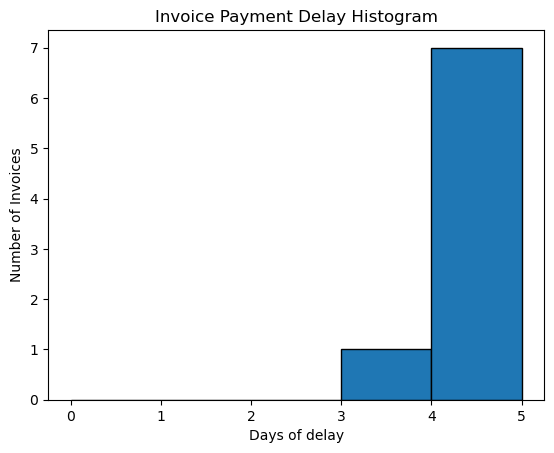

In [6]:
# Convert 'Invoice Date' and 'Payment_Date' to datetime
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df['Payment Date'] = pd.to_datetime(df['Payment Date'])

# Calculate payment delay in days
df['Payment Delay'] = (df['Payment Date'] - df['Invoice Date']).dt.days

# Filter out unpaid invoices for delay calculation
payment_delay = df[df['Status'] == 'Paid']['Payment Delay'].dropna()

# Calculate the maximum payment delay for histogram binning
max_delay = int(payment_delay.max())

# Create a histogram
plt.hist(payment_delay, bins=range(0, max_delay + 1), edgecolor='black')

# Add labels, title, and ticks
plt.xlabel('Days of delay')
plt.ylabel('Number of Invoices')
plt.title('Invoice Payment Delay Histogram')
plt.xticks(range(0, max_delay + 1))

# Show the plot
plt.show()

### Monthly Revenue Trend Line

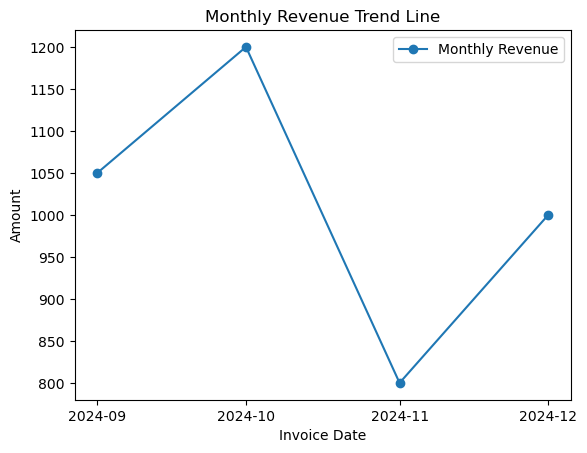

In [7]:
# Convert 'Invoice Date' to datetime
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

# Filter for paid invoices only
paid_invoices = df[df['Status'] == 'Paid']

# Group by month and sum the amounts for paid invoices
monthly_revenue = paid_invoices.groupby(paid_invoices['Invoice Date'].dt.to_period('M'))['Amount'].sum().reset_index()

# Convert 'Invoice Date' back to timestamp for plotting
monthly_revenue['Invoice Date'] = monthly_revenue['Invoice Date'].dt.to_timestamp()  # Convert back to timestamp for plotting

# Plotting the monthly revenue trend line
plt.plot(monthly_revenue['Invoice Date'], monthly_revenue['Amount'], label='Monthly Revenue', marker='o')

# Set x-axis major locator to show fewer date ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Change interval as needed
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format the date labels

# Add labels, title, and legend
plt.xlabel('Invoice Date')
plt.ylabel('Amount')
plt.title('Monthly Revenue Trend Line')
plt.legend()

# Show the plot
plt.show()

## Linear Regression 

In [8]:
# Prepare data for linear regression using monthly revenue DataFrame
monthly_revenue['Month'] = monthly_revenue['Invoice Date'].dt.month
monthly_revenue['Year'] = monthly_revenue['Invoice Date'].dt.year

# Create features (X) and target (y)
X = monthly_revenue[['Year', 'Month']]
y = monthly_revenue['Amount']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Display the results
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

# Predict next month's revenue (assuming the next month is December 2024)
next_month = pd.DataFrame({'Year': [2024], 'Month': [12]})  # Create DataFrame for prediction
predicted_revenue = model.predict(next_month)

print("Predicted revenue for December 2024:", predicted_revenue[0])

Mean Absolute Error: 228.57142857142856
Mean Squared Error: 52244.89795918367
Predicted revenue for December 2024: 907.1428571428571


## Scatter Plot With Regression Line

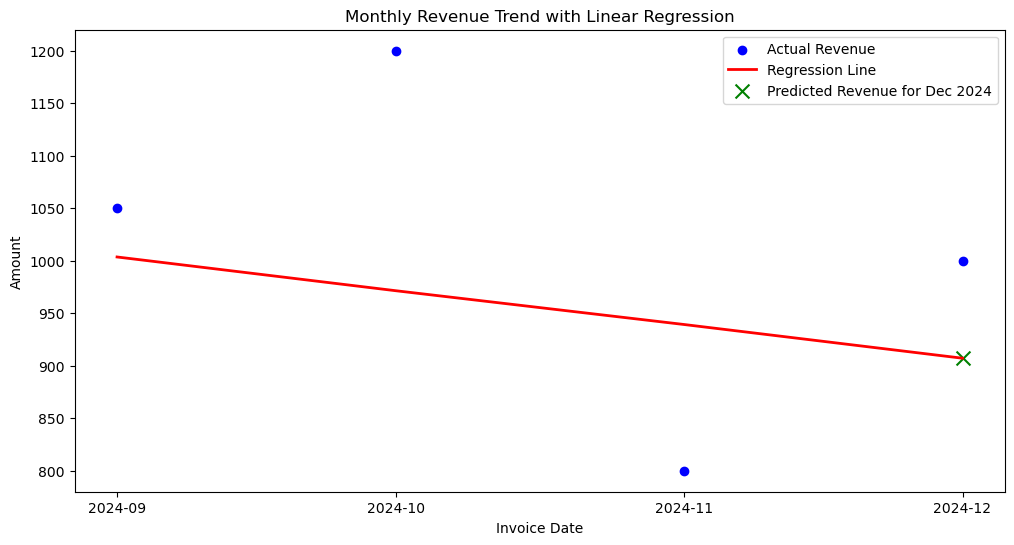

In [9]:
# Plotting the actual monthly revenue and the regression line
plt.figure(figsize=(12, 6))

# Scatter plot of actual monthly revenue
plt.scatter(monthly_revenue['Invoice Date'], monthly_revenue['Amount'], color='blue', label='Actual Revenue', marker='o')

# Create a DataFrame for the regression line
# Generate a range of months for the regression line
months_range = pd.date_range(start=monthly_revenue['Invoice Date'].min(), 
                              end=pd.Timestamp(year=2024, month=12, day=1), 
                              freq='MS')

# Prepare the features for the regression line
X_line = pd.DataFrame({
    'Year': months_range.year,
    'Month': months_range.month
})

# Predict the revenue for the range of months
y_line = model.predict(X_line)

# Plot the regression line
plt.plot(months_range, y_line, color='red', label='Regression Line', linewidth=2)

# Highlight the predicted revenue for December 2024
plt.scatter(pd.Timestamp(year=2024, month=12, day=1), predicted_revenue[0], color='green', 
            label='Predicted Revenue for Dec 2024', marker='x', s=100)

# Add labels, title, and legend
plt.xlabel('Invoice Date')
plt.ylabel('Amount')
plt.title('Monthly Revenue Trend with Linear Regression')
plt.legend()

# Set x-axis major locator to show fewer date ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Show the plot
plt.show()